In [1]:
import numpy as np
from utils.data_utils import TitanicDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset(normalize=False, one_hot=False)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 9), (179, 9), (712,), (179,))

In [3]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,UncommonTitle,YoungTitle
709,3,male,28.0,1,1,15.2458,C,0,1
439,2,male,31.0,0,0,10.5000,S,0,0
840,3,male,20.0,0,0,7.9250,S,0,0
720,2,female,6.0,0,1,33.0000,S,0,1
39,3,female,14.0,1,0,11.2417,C,0,1


In [4]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

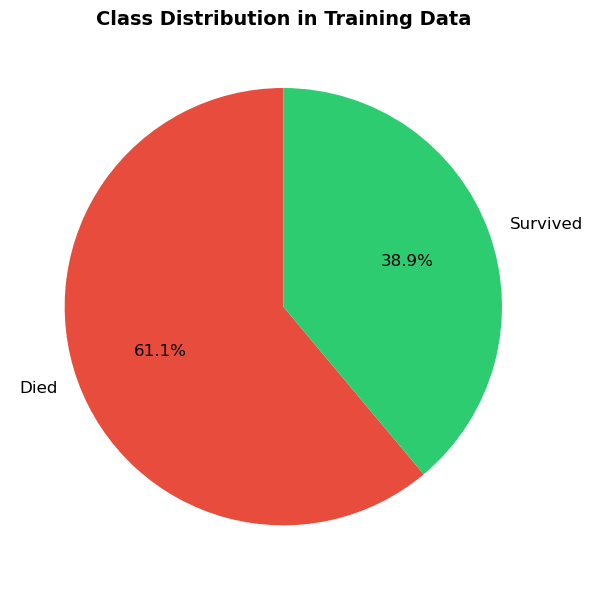

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [5]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

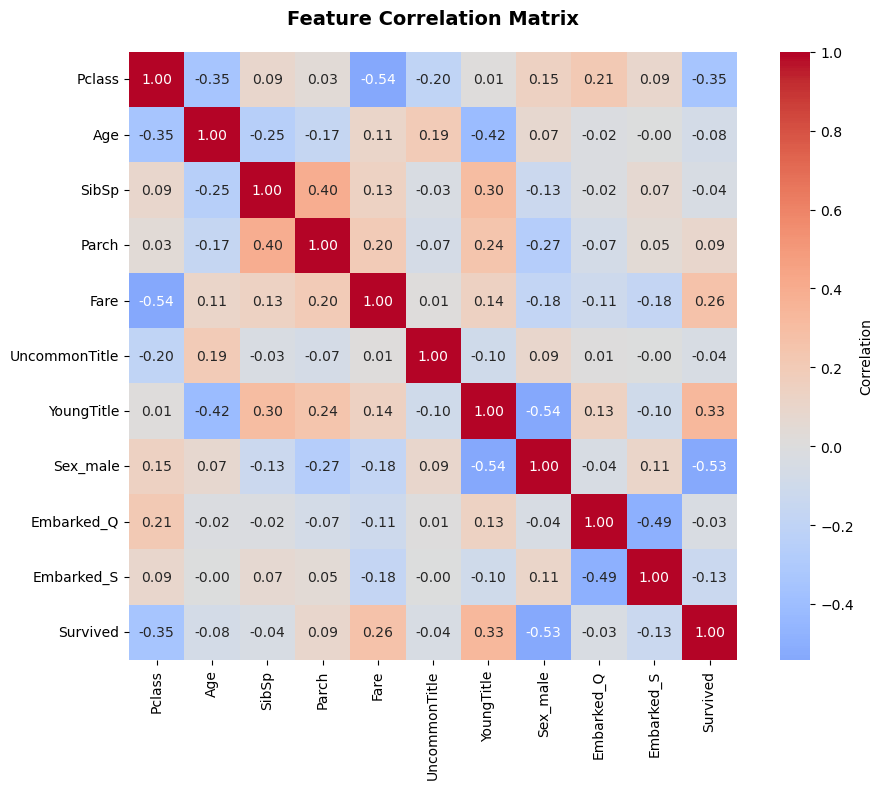

In [6]:
TitanicDataHelper.plot_correlation(x_train, y_train)

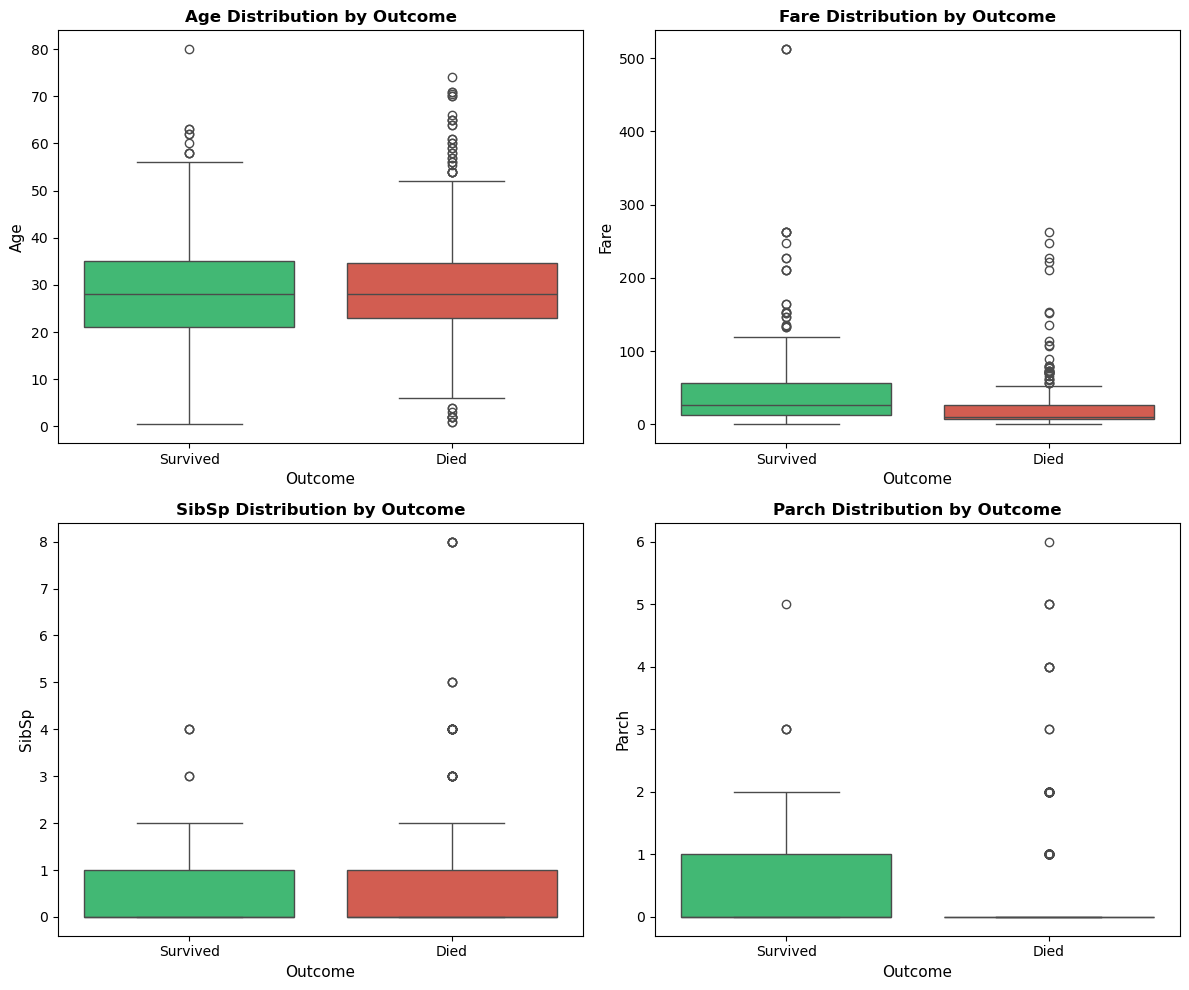

In [7]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [8]:
x_survived = x_train[y_train == 1]
x_died = x_train[y_train == 0]

In [9]:
survived_prior = len(x_survived) / len(x_train)
died_prior = len(x_died) / len(x_train)

priors = {
    1: survived_prior,
    0: died_prior
}

In [10]:
gaussian_columns = ["Fare", "Age"]
x_survived_gaussian = x_survived[gaussian_columns]
x_died_gaussian = x_survived[gaussian_columns]

x_survived_means = np.mean(x_survived_gaussian, axis=0)
x_survived_vars = np.var(x_survived_gaussian, axis=0)

x_died_means = np.mean(x_died_gaussian, axis=0)
x_died_vars = np.var(x_died_gaussian, axis=0)

means = {
    1: x_survived_means,
    0: x_died_means
}

variances = {
    1: x_survived_vars,
    0: x_died_vars
}

In [11]:
def compute_gaussian_probability(x, feature_name):
    survived_feature_mean = means[1][feature_name]
    died_feature_mean = means[0][feature_name]
    
    survived_feature_var = variances[1][feature_name]
    died_feature_var = variances[0][feature_name]
    
    a1 = 1 / np.sqrt(2 * np.pi * survived_feature_var)
    b1 = (x[feature_name] - survived_feature_mean) ** 2
    c1 = 2 * survived_feature_var
    
    survived_feature_prob = a1 * np.exp(-b1 / c1)
    
    a2 = 1 / np.sqrt(2 * np.pi * died_feature_var)
    b2 = (x[feature_name] - died_feature_mean) ** 2
    c2 = 2 * died_feature_var
    
    died_feature_prob = a2 * np.exp(-b2 / c2)
    
    return survived_feature_prob, died_feature_prob

In [12]:
categorical_columns = ["Pclass", "Sex", "Embarked", "SibSp", "Parch", "UncommonTitle", "YoungTitle"]

x_survived_categorical = x_survived[categorical_columns]
x_died_categorical = x_died[categorical_columns]

x_survived_category_counts = {
    "Sex": x_survived_categorical["Sex"].value_counts(),
    "Pclass": x_survived_categorical["Pclass"].value_counts(),
    "Embarked": x_survived_categorical["Embarked"].value_counts(),
    "SibSp": x_survived_categorical["SibSp"].value_counts(),
    "Parch": x_survived_categorical["Parch"].value_counts(),
    "UncommonTitle": x_survived_categorical["UncommonTitle"].value_counts(),
    "YoungTitle": x_survived_categorical["YoungTitle"].value_counts()
}

x_died_category_counts = {
    "Sex": x_died_categorical["Sex"].value_counts(),
    "Pclass": x_died_categorical["Pclass"].value_counts(),
    "Embarked": x_died_categorical["Embarked"].value_counts(),
    "SibSp": x_died_categorical["SibSp"].value_counts(),
    "Parch": x_died_categorical["Parch"].value_counts(),
    "UncommonTitle": x_died_categorical["UncommonTitle"].value_counts(),
    "YoungTitle": x_died_categorical["YoungTitle"].value_counts()
}

In [13]:
def compute_categorical_probability(x, feature_name, smoothing=1.0):
    vocab_size = len(x_survived_category_counts[feature_name])
    
    survived_category_frequency = x_survived_category_counts[feature_name].get(x[feature_name], 0)
    died_category_frequency = x_died_category_counts[feature_name].get(x[feature_name], 0)
    
    survived_total_frequency = x_survived_category_counts[feature_name].sum()
    died_total_frequency = x_died_category_counts[feature_name].sum()
    
    a1 = survived_category_frequency + smoothing
    b1 = survived_total_frequency + (smoothing * vocab_size) 
    
    survived_feature_prob = a1 / b1
    
    a2 = died_category_frequency + smoothing
    b2 = died_total_frequency + (smoothing * vocab_size)
    
    died_feature_prob = a2 / b2
    
    return survived_feature_prob, died_feature_prob

In [14]:
def compute_class_probabilities(x):
    survived_score = np.log(priors[1])
    died_score = np.log(priors[0])
    
    for feature_name in x.index:
        if feature_name in categorical_columns:
            survived_feature_prob, died_feature_prob = compute_categorical_probability(x, feature_name)
        else:    
            survived_feature_prob, died_feature_prob = compute_gaussian_probability(x, feature_name)
        
        survived_score += np.log(survived_feature_prob)
        died_score += np.log(died_feature_prob)
    
    return survived_score, died_score

## Model Evaluation

In [15]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    survived_score, died_score = compute_class_probabilities(x)
    prediction = survived_score > died_score
    predictions.append(prediction)
    
    prob_survived = 1 / (1 + np.exp(-(survived_score - died_score)))
    probabilities.append(prob_survived)

predictions = np.array(predictions)
probabilities = np.array(probabilities)
y_test_array = y_test.values

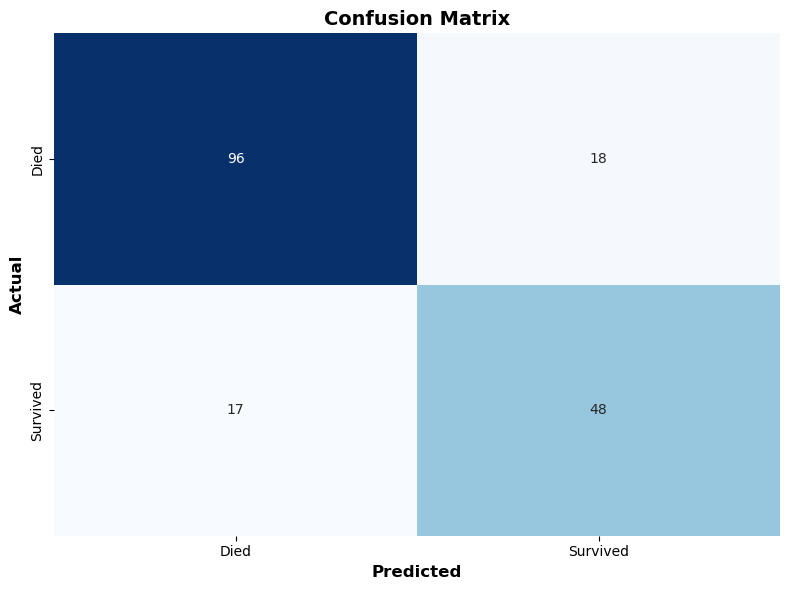

True Negatives: 96
False Positives: 18
False Negatives: 17
True Positives: 48

Sensitivity (Recall): 0.7385
Specificity: 0.8421
Precision: 0.7273
Accuracy: 0.8045
F1 Score: 0.7328


In [16]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Died", "Survived"])

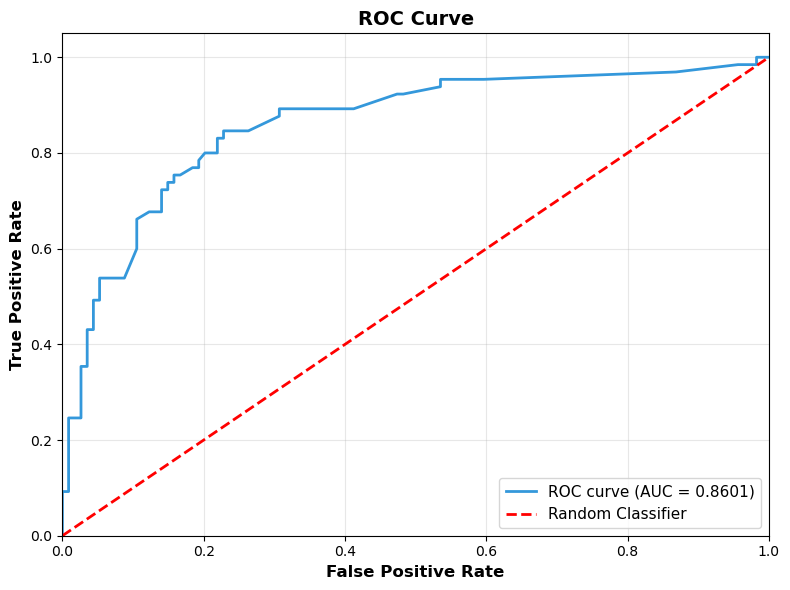

Area Under the Curve (AUC): 0.8601


In [17]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)

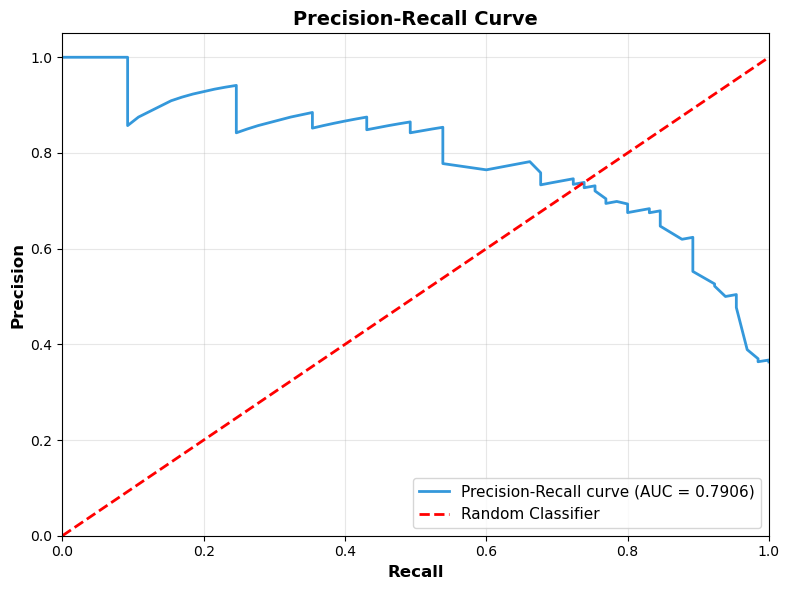

Area Under the Curve (AUC): 0.7906


In [18]:
EvaluationHelper.plot_precision_recall_curve(y_test, probabilities)